# Volve Oil Production Data Science Project
## Notebook 02: Production Decline and Feature Analysis

### Purpose

This notebook investigates production decline, temporal behaviour, and candidate predictive features using the patterns identified during the dataset audit and exploratory analysis.

The analysis focuses on distinguishing long-term production decline from operational interruptions, examining well-specific production trajectories, and determining which variables and forecasting targets are appropriate for later machine learning modelling.

No machine learning model is selected in this notebook. The objective is to establish an evidence-based modelling problem before model development begins.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy


PROJECT_ROOT = Path(
    r"F:\DataScience_Projects\Volve_Oil_Production"
)

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Volve production data.xlsx"
)

NOTEBOOK01_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "01_eda"
)

DECLINE_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "02_decline_feature_analysis"
)

DECLINE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Raw dataset exists:",
    RAW_DATA_PATH.exists()
)

print(
    "Notebook 01 outputs exist:",
    NOTEBOOK01_OUTPUT_DIR.exists()
)

print(
    "Notebook 02 output directory:",
    DECLINE_OUTPUT_DIR
)

Raw dataset exists: True
Notebook 01 outputs exist: True
Notebook 02 output directory: F:\DataScience_Projects\Volve_Oil_Production\outputs\02_decline_feature_analysis


In [2]:
print(
    "SciPy version:",
    scipy.__version__
)

SciPy version: 1.18.0


## 1. Data Preparation for Decline Analysis

The daily production dataset is loaded again so that the decline-analysis dataset can be constructed reproducibly from the original source.

Only records classified as production are used for producer decline analysis. The raw workbook is not modified.

In [3]:
daily_df = pd.read_excel(
    RAW_DATA_PATH,
    sheet_name="Daily Production Data"
)


daily_df["DATEPRD"] = pd.to_datetime(
    daily_df["DATEPRD"]
)


production_df = (
    daily_df[
        daily_df["FLOW_KIND"] == "production"
    ]
    .copy()
    .sort_values(
        [
            "NPD_WELL_BORE_NAME",
            "DATEPRD"
        ]
    )
)


print(
    "Daily dataset shape:",
    daily_df.shape
)

print(
    "Production records:",
    len(production_df)
)

print(
    "Producer wells:",
    production_df[
        "NPD_WELL_BORE_NAME"
    ].nunique()
)

print(
    "Production coverage:",
    production_df["DATEPRD"].min(),
    "to",
    production_df["DATEPRD"].max()
)

Daily dataset shape: (15634, 24)
Production records: 9161
Producer wells: 6
Production coverage: 2008-02-12 00:00:00 to 2016-09-17 00:00:00


## 2. Construction of the Well-Month Decline Dataset

Production decline is analysed at monthly well level rather than solely by calendar date.

Because producer wells entered production at different times, a production-age variable is constructed for each well. Production age represents the number of months since the well's first active production month.

This allows wells with different calendar start dates to be compared at similar stages of their observed producing lives.

In [4]:
production_df["YEAR_MONTH"] = (
    production_df["DATEPRD"]
    .dt.to_period("M")
)


well_monthly_decline = (
    production_df
    .groupby(
        [
            "NPD_WELL_BORE_NAME",
            "YEAR_MONTH"
        ],
        as_index=False
    )
    .agg(
        oil_volume=(
            "BORE_OIL_VOL",
            "sum"
        ),

        gas_volume=(
            "BORE_GAS_VOL",
            "sum"
        ),

        water_volume=(
            "BORE_WAT_VOL",
            "sum"
        ),

        on_stream_hours=(
            "ON_STREAM_HRS",
            "sum"
        )
    )
)


well_monthly_decline["DATE"] = (
    well_monthly_decline[
        "YEAR_MONTH"
    ]
    .dt.to_timestamp()
)


print(
    "Producer-month observations:",
    len(well_monthly_decline)
)

display(
    well_monthly_decline.head(10)
)

Producer-month observations: 311


,NPD_WELL_BORE_NAME,YEAR_MONTH,oil_volume,gas_volume,water_volume,on_stream_hours,DATE
0,15/9-F-1 C,2014-04,11142.47,1597936.65,0.00,227.50000,2014-04-01
1,15/9-F-1 C,2014-05,24901.95,3496229.65,783.48,733.83334,2014-05-01
2,15/9-F-1 C,2014-06,19617.76,2886661.69,2068.48,705.91666,2014-06-01
3,15/9-F-1 C,2014-07,15085.68,2249365.75,6243.98,742.41666,2014-07-01
4,15/9-F-1 C,2014-08,6970.43,1048190.80,4529.75,432.99166,2014-08-01
5,15/9-F-1 C,2014-09,9168.43,1414099.99,8317.59,630.30000,2014-09-01
6,15/9-F-1 C,2014-10,9468.06,1462063.99,10364.87,745.00000,2014-10-01
7,15/9-F-1 C,2014-11,6710.33,1044188.30,7234.24,579.77500,2014-11-01
8,15/9-F-1 C,2014-12,120.29,25857.08,183.44,27.50000,2014-12-01
9,15/9-F-1 C,2015-01,10875.53,1604934.60,6850.80,479.91667,2015-01-01


In [5]:
first_active_month = (
    well_monthly_decline[
        well_monthly_decline[
            "on_stream_hours"
        ] > 0
    ]
    .groupby(
        "NPD_WELL_BORE_NAME"
    )["DATE"]
    .min()
    .rename(
        "first_active_month"
    )
)


well_monthly_decline = (
    well_monthly_decline
    .merge(
        first_active_month,
        on="NPD_WELL_BORE_NAME",
        how="left"
    )
)


well_monthly_decline[
    "production_age_months"
] = (
    (
        well_monthly_decline["DATE"].dt.year
        -
        well_monthly_decline[
            "first_active_month"
        ].dt.year
    )
    * 12

    +

    (
        well_monthly_decline["DATE"].dt.month
        -
        well_monthly_decline[
            "first_active_month"
        ].dt.month
    )
)


display(
    well_monthly_decline[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "first_active_month",
            "production_age_months",
            "oil_volume",
            "on_stream_hours"
        ]
    ]
    .head(15)
)

,NPD_WELL_BORE_NAME,DATE,first_active_month,production_age_months,oil_volume,on_stream_hours
0,15/9-F-1 C,2014-04-01,2014-04-01,0,11142.47,227.50000
1,15/9-F-1 C,2014-05-01,2014-04-01,1,24901.95,733.83334
2,15/9-F-1 C,2014-06-01,2014-04-01,2,19617.76,705.91666
3,15/9-F-1 C,2014-07-01,2014-04-01,3,15085.68,742.41666
4,15/9-F-1 C,2014-08-01,2014-04-01,4,6970.43,432.99166
5,15/9-F-1 C,2014-09-01,2014-04-01,5,9168.43,630.30000
6,15/9-F-1 C,2014-10-01,2014-04-01,6,9468.06,745.00000
7,15/9-F-1 C,2014-11-01,2014-04-01,7,6710.33,579.77500
8,15/9-F-1 C,2014-12-01,2014-04-01,8,120.29,27.50000
9,15/9-F-1 C,2015-01-01,2014-04-01,9,10875.53,479.91667


In [6]:
production_age_summary = (
    well_monthly_decline
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .agg(
        first_recorded_month=(
            "DATE",
            "min"
        ),

        first_active_month=(
            "first_active_month",
            "first"
        ),

        final_recorded_month=(
            "DATE",
            "max"
        ),

        maximum_production_age_months=(
            "production_age_months",
            "max"
        ),

        monthly_records=(
            "DATE",
            "size"
        )
    )
    .reset_index()
)


display(
    production_age_summary
)

,NPD_WELL_BORE_NAME,first_recorded_month,first_active_month,final_recorded_month,maximum_production_age_months,monthly_records
0,15/9-F-1 C,2014-04-01,2014-04-01,2016-04-01,24,25
1,15/9-F-11,2013-07-01,2013-07-01,2016-09-01,38,39
2,15/9-F-12,2008-02-01,2008-02-01,2016-09-01,103,104
3,15/9-F-14,2008-02-01,2008-07-01,2016-09-01,98,104
4,15/9-F-15 D,2014-01-01,2014-01-01,2016-09-01,32,33
5,15/9-F-5,2016-04-01,2016-04-01,2016-09-01,5,6


### 2.1 Separation of Recorded and Active Production Life

The producer-month dataset may contain records before a well's first active production month or during later shutdown periods.

These observations are operationally meaningful and are retained in the complete well-month dataset. However, production-decline analysis should begin only after the first active production month.

A separate active-production dataset is therefore created for decline analysis while the complete dataset is retained for studying downtime and operational interruptions.

In [7]:
pre_active_records = (
    well_monthly_decline[
        well_monthly_decline[
            "production_age_months"
        ] < 0
    ]
    .copy()
)


print(
    "Pre-active producer-month records:",
    len(pre_active_records)
)


display(
    pre_active_records[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "first_active_month",
            "production_age_months",
            "oil_volume",
            "on_stream_hours"
        ]
    ]
)

Pre-active producer-month records: 5


,NPD_WELL_BORE_NAME,DATE,first_active_month,production_age_months,oil_volume,on_stream_hours
168,15/9-F-14,2008-02-01,2008-07-01,-5,0.0,0.0
169,15/9-F-14,2008-03-01,2008-07-01,-4,0.0,0.0
170,15/9-F-14,2008-04-01,2008-07-01,-3,0.0,0.0
171,15/9-F-14,2008-05-01,2008-07-01,-2,0.0,0.0
172,15/9-F-14,2008-06-01,2008-07-01,-1,0.0,0.0


In [8]:
well_monthly_decline[
    "monthly_activity_state"
] = np.select(
    [
        well_monthly_decline[
            "on_stream_hours"
        ] > 0,

        well_monthly_decline[
            "on_stream_hours"
        ] == 0
    ],
    [
        "active",
        "inactive"
    ],
    default="unknown"
)


monthly_activity_summary = (
    well_monthly_decline
    .groupby(
        [
            "NPD_WELL_BORE_NAME",
            "monthly_activity_state"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)


display(
    monthly_activity_summary
)

monthly_activity_state,active,inactive
NPD_WELL_BORE_NAME,,
15/9-F-1 C,25,0
15/9-F-11,39,0
15/9-F-12,102,2
15/9-F-14,97,7
15/9-F-15 D,30,3
15/9-F-5,5,1


In [9]:
active_decline_df = (
    well_monthly_decline[
        (
            well_monthly_decline[
                "production_age_months"
            ] >= 0
        )
        &
        (
            well_monthly_decline[
                "on_stream_hours"
            ] > 0
        )
    ]
    .copy()
    .sort_values(
        [
            "NPD_WELL_BORE_NAME",
            "production_age_months"
        ]
    )
)


print(
    "All producer-month observations:",
    len(well_monthly_decline)
)

print(
    "Active decline observations:",
    len(active_decline_df)
)

print(
    "Producer wells retained:",
    active_decline_df[
        "NPD_WELL_BORE_NAME"
    ].nunique()
)

All producer-month observations: 311
Active decline observations: 298
Producer wells retained: 6


In [10]:
active_decline_summary = (
    active_decline_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .agg(
        active_monthly_observations=(
            "DATE",
            "size"
        ),

        first_active_observation=(
            "DATE",
            "min"
        ),

        last_active_observation=(
            "DATE",
            "max"
        ),

        minimum_production_age=(
            "production_age_months",
            "min"
        ),

        maximum_production_age=(
            "production_age_months",
            "max"
        )
    )
    .reset_index()
)


display(
    active_decline_summary
)

,NPD_WELL_BORE_NAME,active_monthly_observations,first_active_observation,last_active_observation,minimum_production_age,maximum_production_age
0,15/9-F-1 C,25,2014-04-01,2016-04-01,0,24
1,15/9-F-11,39,2013-07-01,2016-09-01,0,38
2,15/9-F-12,102,2008-02-01,2016-08-01,0,102
3,15/9-F-14,97,2008-07-01,2016-07-01,0,96
4,15/9-F-15 D,30,2014-01-01,2016-07-01,0,30
5,15/9-F-5,5,2016-04-01,2016-08-01,0,4


## 3. Production Decline by Calendar Time and Production Age

Oil production is first examined using two different time representations.

Calendar time shows when each well contributed to field production, while production age aligns wells according to the number of months since their first active production month.

The production-age view allows wells that began producing in different calendar years to be compared at similar stages of their observed producing lives.

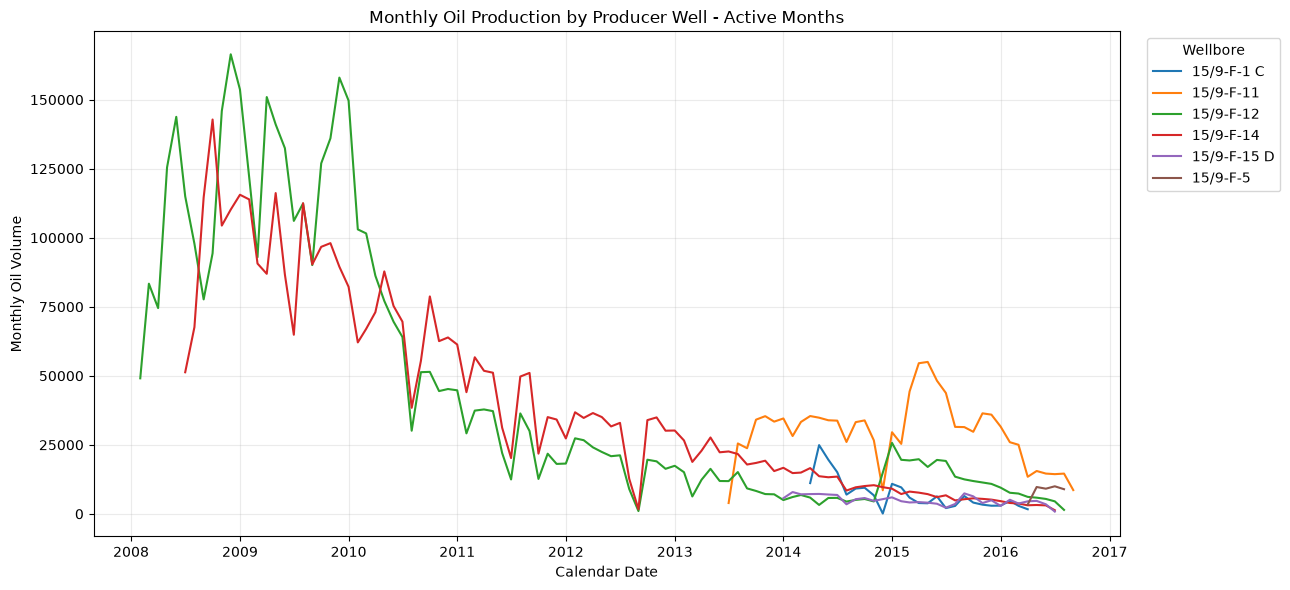

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\02_decline_feature_analysis\01_active_monthly_oil_by_calendar_time.png


In [11]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)


for well_name, group in (
    active_decline_df.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    ax.plot(
        group["DATE"],
        group["oil_volume"],
        linewidth=1.5,
        label=well_name
    )


ax.set_title(
    "Monthly Oil Production by Producer Well - Active Months"
)

ax.set_xlabel(
    "Calendar Date"
)

ax.set_ylabel(
    "Monthly Oil Volume"
)

ax.legend(
    title="Wellbore",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


figure_path = (
    DECLINE_OUTPUT_DIR
    / "01_active_monthly_oil_by_calendar_time.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Figure saved:",
    figure_path
)

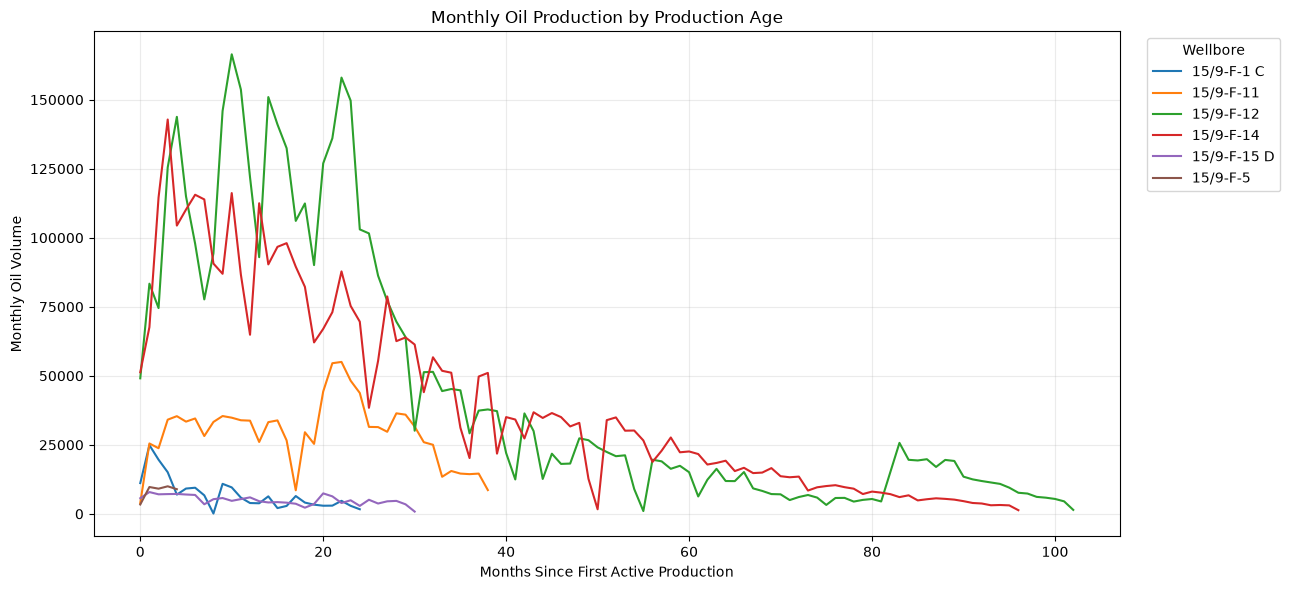

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\02_decline_feature_analysis\02_oil_production_by_production_age.png


In [12]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)


for well_name, group in (
    active_decline_df.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    ax.plot(
        group[
            "production_age_months"
        ],
        group[
            "oil_volume"
        ],
        linewidth=1.5,
        label=well_name
    )


ax.set_title(
    "Monthly Oil Production by Production Age"
)

ax.set_xlabel(
    "Months Since First Active Production"
)

ax.set_ylabel(
    "Monthly Oil Volume"
)

ax.legend(
    title="Wellbore",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


figure_path = (
    DECLINE_OUTPUT_DIR
    / "02_oil_production_by_production_age.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Figure saved:",
    figure_path
)

### 3.1 Production Intensity Across Well Life

Monthly oil volume can fall because of reduced operating time as well as declining production performance.

To reduce the direct effect of varying operating duration, oil production is normalised by monthly on-stream hours. The resulting measure represents oil volume produced per on-stream hour and is used as an exploratory indicator of production intensity.

In [13]:
active_decline_df[
    "oil_per_on_stream_hour"
] = (
    active_decline_df[
        "oil_volume"
    ]
    /
    active_decline_df[
        "on_stream_hours"
    ]
)


print(
    "Missing normalized values:",
    active_decline_df[
        "oil_per_on_stream_hour"
    ].isna().sum()
)

print(
    "Infinite normalized values:",
    np.isinf(
        active_decline_df[
            "oil_per_on_stream_hour"
        ]
    ).sum()
)

Missing normalized values: 0
Infinite normalized values: 0


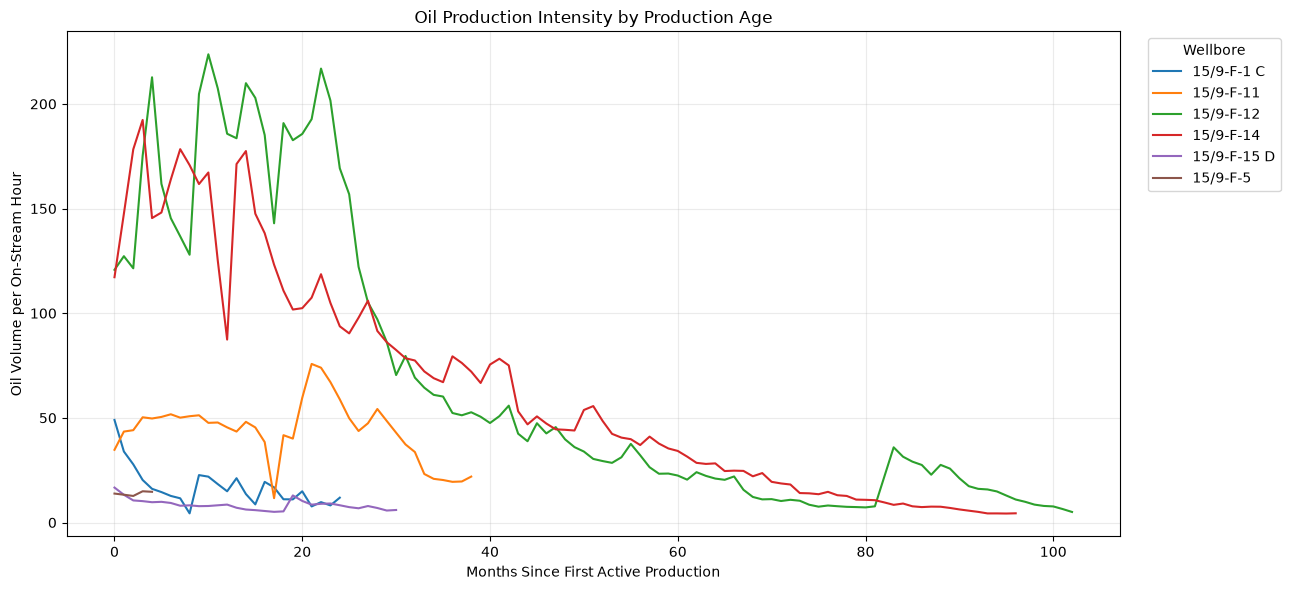

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\02_decline_feature_analysis\03_oil_productivity_by_production_age.png


In [14]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)


for well_name, group in (
    active_decline_df.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    ax.plot(
        group[
            "production_age_months"
        ],
        group[
            "oil_per_on_stream_hour"
        ],
        linewidth=1.5,
        label=well_name
    )


ax.set_title(
    "Oil Production Intensity by Production Age"
)

ax.set_xlabel(
    "Months Since First Active Production"
)

ax.set_ylabel(
    "Oil Volume per On-Stream Hour"
)

ax.legend(
    title="Wellbore",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


figure_path = (
    DECLINE_OUTPUT_DIR
    / "03_oil_productivity_by_production_age.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Figure saved:",
    figure_path
)

### 3.2 Quantifying Observed Production Decline

The production-age curves indicate substantial differences in both production scale and decline behaviour across wells.

To quantify these patterns, the observed peak production level and peak production intensity are identified for each producer. Early-life and late-life production intensity are also compared for wells with sufficient production history.

These statistics are descriptive and do not yet represent fitted decline-curve parameters.

In [15]:
peak_oil_indices = (
    active_decline_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )["oil_volume"]
    .idxmax()
)


peak_oil_summary = (
    active_decline_df
    .loc[
        peak_oil_indices,
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "production_age_months",
            "oil_volume"
        ]
    ]
    .rename(
        columns={
            "DATE":
                "peak_oil_month",

            "production_age_months":
                "peak_oil_age_months",

            "oil_volume":
                "peak_monthly_oil"
        }
    )
)


peak_intensity_indices = (
    active_decline_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )[
        "oil_per_on_stream_hour"
    ]
    .idxmax()
)


peak_intensity_summary = (
    active_decline_df
    .loc[
        peak_intensity_indices,
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "production_age_months",
            "oil_per_on_stream_hour"
        ]
    ]
    .rename(
        columns={
            "DATE":
                "peak_intensity_month",

            "production_age_months":
                "peak_intensity_age_months",

            "oil_per_on_stream_hour":
                "peak_oil_per_on_stream_hour"
        }
    )
)


well_peak_summary = (
    peak_oil_summary
    .merge(
        peak_intensity_summary,
        on="NPD_WELL_BORE_NAME",
        how="left"
    )
)


display(
    well_peak_summary
)

,NPD_WELL_BORE_NAME,peak_oil_month,peak_oil_age_months,peak_monthly_oil,peak_intensity_month,peak_intensity_age_months,peak_oil_per_on_stream_hour
0,15/9-F-1 C,2014-05-01,1,24901.95,2014-04-01,0,48.977890
1,15/9-F-11,2015-05-01,22,55029.22,2015-04-01,21,75.771889
2,15/9-F-12,2008-12-01,10,166439.67,2008-12-01,10,223.709234
3,15/9-F-14,2008-10-01,3,142817.06,2008-10-01,3,192.346209
4,15/9-F-15 D,2014-02-01,1,7898.60,2014-01-01,0,16.694180
5,15/9-F-5,2016-07-01,3,9985.29,2016-07-01,3,14.933694


In [16]:
decline_change_rows = []


for well_name, group in (
    active_decline_df.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    group = (
        group
        .sort_values(
            "production_age_months"
        )
        .reset_index(
            drop=True
        )
    )

    observation_count = len(group)


    if observation_count >= 12:

        early_intensity = (
            group
            .head(6)[
                "oil_per_on_stream_hour"
            ]
            .median()
        )

        late_intensity = (
            group
            .tail(6)[
                "oil_per_on_stream_hour"
            ]
            .median()
        )

        intensity_change_pct = (
            (
                late_intensity
                -
                early_intensity
            )
            /
            early_intensity
            * 100
        )

    else:

        early_intensity = np.nan
        late_intensity = np.nan
        intensity_change_pct = np.nan


    decline_change_rows.append({
        "well":
            well_name,

        "active_monthly_observations":
            observation_count,

        "early_6_observation_median_intensity":
            early_intensity,

        "late_6_observation_median_intensity":
            late_intensity,

        "early_to_late_intensity_change_pct":
            intensity_change_pct
    })


decline_change_summary = (
    pd.DataFrame(
        decline_change_rows
    )
)


decline_change_summary[
    [
        "early_6_observation_median_intensity",
        "late_6_observation_median_intensity",
        "early_to_late_intensity_change_pct"
    ]
] = (
    decline_change_summary[
        [
            "early_6_observation_median_intensity",
            "late_6_observation_median_intensity",
            "early_to_late_intensity_change_pct"
        ]
    ]
    .round(2)
)


display(
    decline_change_summary
)

,well,active_monthly_observations,early_6_observation_median_intensity,late_6_observation_median_intensity,early_to_late_intensity_change_pct
0,15/9-F-1 C,25,24.06,10.40,-56.77
1,15/9-F-11,39,46.91,20.59,-56.10
2,15/9-F-12,102,144.52,7.81,-94.60
3,15/9-F-14,97,147.82,4.38,-97.04
4,15/9-F-15 D,30,10.39,6.87,-33.85
5,15/9-F-5,5,NaN,NaN,NaN


In [17]:
age_intensity_relationship = (
    active_decline_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .apply(
        lambda group:
            group[
                [
                    "production_age_months",
                    "oil_per_on_stream_hour"
                ]
            ]
            .corr(
                method="spearman"
            )
            .iloc[0, 1]
        if len(group) >= 12
        else np.nan
    )
    .rename(
        "spearman_age_intensity_correlation"
    )
    .reset_index()
)


age_intensity_relationship[
    "spearman_age_intensity_correlation"
] = (
    age_intensity_relationship[
        "spearman_age_intensity_correlation"
    ]
    .round(4)
)


display(
    age_intensity_relationship
)

,NPD_WELL_BORE_NAME,spearman_age_intensity_correlation
0,15/9-F-1 C,-0.6115
1,15/9-F-11,-0.3919
2,15/9-F-12,-0.9152
3,15/9-F-14,-0.9891
4,15/9-F-15 D,-0.5395
5,15/9-F-5,NaN


## 4. Post-Peak Production Decline

Producer wells do not necessarily enter a declining phase immediately after first production. Some wells experience ramp-up periods or reach their highest production intensity later in their observed producing life.

For this reason, decline behaviour is examined from each well's observed peak production intensity onward.

The peak is used as an empirical reference point rather than being interpreted as a documented reservoir-engineering event. Production intensity after the peak is normalised relative to the well-specific peak so that wells with substantially different production scales can be compared on a common basis.

In [18]:
peak_reference = (
    peak_intensity_summary[
        [
            "NPD_WELL_BORE_NAME",
            "peak_intensity_month",
            "peak_intensity_age_months",
            "peak_oil_per_on_stream_hour"
        ]
    ]
    .copy()
)


post_peak_decline_df = (
    active_decline_df
    .merge(
        peak_reference,
        on="NPD_WELL_BORE_NAME",
        how="left"
    )
)


post_peak_decline_df = (
    post_peak_decline_df[
        post_peak_decline_df[
            "production_age_months"
        ]
        >=
        post_peak_decline_df[
            "peak_intensity_age_months"
        ]
    ]
    .copy()
)


post_peak_decline_df[
    "months_since_peak"
] = (
    post_peak_decline_df[
        "production_age_months"
    ]
    -
    post_peak_decline_df[
        "peak_intensity_age_months"
    ]
)


post_peak_decline_df[
    "relative_intensity"
] = (
    post_peak_decline_df[
        "oil_per_on_stream_hour"
    ]
    /
    post_peak_decline_df[
        "peak_oil_per_on_stream_hour"
    ]
)


print(
    "Post-peak observations:",
    len(post_peak_decline_df)
)

print(
    "Producer wells retained:",
    post_peak_decline_df[
        "NPD_WELL_BORE_NAME"
    ].nunique()
)

display(
    post_peak_decline_df[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "months_since_peak",
            "oil_per_on_stream_hour",
            "peak_oil_per_on_stream_hour",
            "relative_intensity"
        ]
    ]
    .head(12)
)

Post-peak observations: 261
Producer wells retained: 6


,NPD_WELL_BORE_NAME,DATE,months_since_peak,oil_per_on_stream_hour,peak_oil_per_on_stream_hour,relative_intensity
0,15/9-F-1 C,2014-04-01,0,48.977890,48.97789,1.000000
1,15/9-F-1 C,2014-05-01,1,33.934067,48.97789,0.692845
2,15/9-F-1 C,2014-06-01,2,27.790476,48.97789,0.567409
3,15/9-F-1 C,2014-07-01,3,20.319695,48.97789,0.414875
4,15/9-F-1 C,2014-08-01,4,16.098301,48.97789,0.328685
5,15/9-F-1 C,2014-09-01,5,14.546137,48.97789,0.296994
6,15/9-F-1 C,2014-10-01,6,12.708805,48.97789,0.259480
7,15/9-F-1 C,2014-11-01,7,11.574024,48.97789,0.236311
8,15/9-F-1 C,2014-12-01,8,4.374182,48.97789,0.089309
9,15/9-F-1 C,2015-01-01,9,22.661288,48.97789,0.462684


In [19]:
post_peak_coverage = (
    post_peak_decline_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .agg(
        peak_month=(
            "peak_intensity_month",
            "first"
        ),

        peak_age_months=(
            "peak_intensity_age_months",
            "first"
        ),

        post_peak_observations=(
            "DATE",
            "size"
        ),

        maximum_months_since_peak=(
            "months_since_peak",
            "max"
        ),

        latest_relative_intensity=(
            "relative_intensity",
            "last"
        )
    )
    .reset_index()
)


post_peak_coverage[
    "latest_relative_intensity_pct"
] = (
    post_peak_coverage[
        "latest_relative_intensity"
    ]
    * 100
).round(2)


display(
    post_peak_coverage
)

,NPD_WELL_BORE_NAME,peak_month,peak_age_months,post_peak_observations,maximum_months_since_peak,latest_relative_intensity,latest_relative_intensity_pct
0,15/9-F-1 C,2014-04-01,0,25,24,0.242368,24.24
1,15/9-F-11,2015-04-01,21,18,17,0.289643,28.96
2,15/9-F-12,2008-12-01,10,92,92,0.022547,2.25
3,15/9-F-14,2008-10-01,3,94,93,0.022901,2.29
4,15/9-F-15 D,2014-01-01,0,30,30,0.358679,35.87
5,15/9-F-5,2016-07-01,3,2,1,0.982706,98.27


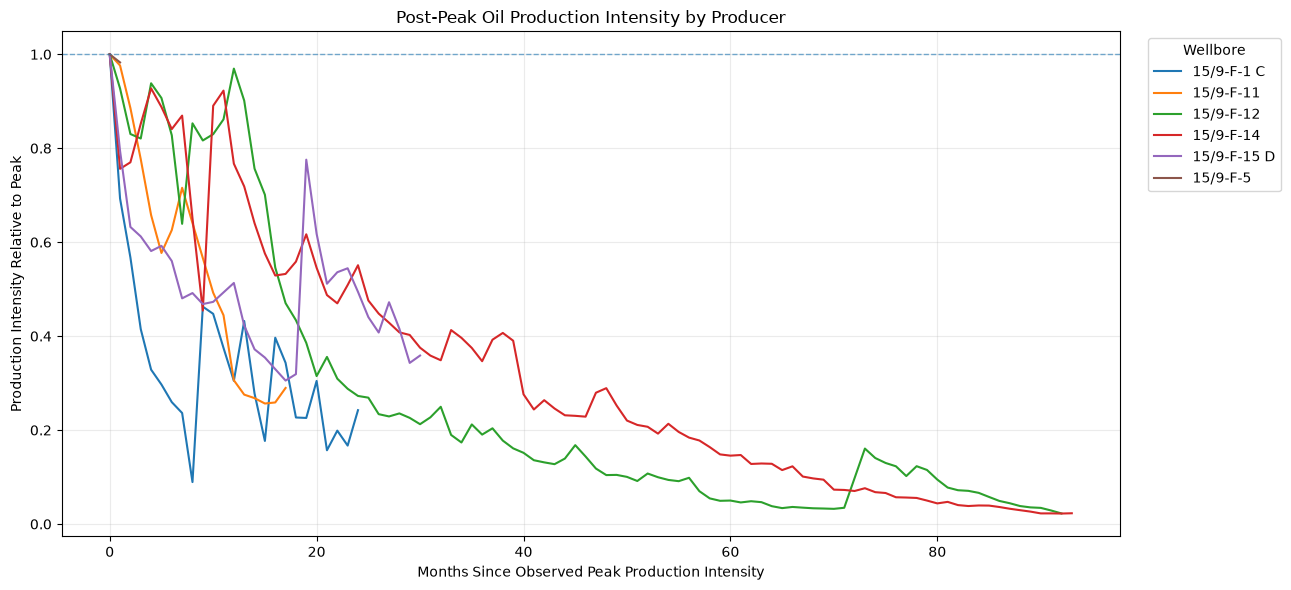

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\02_decline_feature_analysis\04_relative_post_peak_decline_by_well.png


In [20]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)


for well_name, group in (
    post_peak_decline_df.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    group = group.sort_values(
        "months_since_peak"
    )

    ax.plot(
        group[
            "months_since_peak"
        ],
        group[
            "relative_intensity"
        ],
        linewidth=1.5,
        label=well_name
    )


ax.axhline(
    1.0,
    linewidth=1,
    linestyle="--",
    alpha=0.6
)


ax.set_title(
    "Post-Peak Oil Production Intensity by Producer"
)

ax.set_xlabel(
    "Months Since Observed Peak Production Intensity"
)

ax.set_ylabel(
    "Production Intensity Relative to Peak"
)

ax.legend(
    title="Wellbore",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


figure_path = (
    DECLINE_OUTPUT_DIR
    / "04_relative_post_peak_decline_by_well.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Figure saved:",
    figure_path
)

### 4.1 Descriptive Post-Peak Decline Trend

Wells with sufficient post-peak history are evaluated using a simple log-linear decline trend.

If production intensity followed a smooth exponential decline, the logarithm of relative production intensity would decline approximately linearly with time since peak.

This analysis is used only as a descriptive benchmark. It is not treated as a final reservoir decline model because the observed well histories contain operational fluctuations, rebounds, and possible changes in production regime.

In [21]:
eligible_decline_wells = (
    post_peak_coverage[
        post_peak_coverage[
            "post_peak_observations"
        ] >= 12
    ][
        "NPD_WELL_BORE_NAME"
    ]
    .tolist()
)


print(
    "Wells eligible for quantitative "
    "post-peak decline analysis:"
)

for well_name in eligible_decline_wells:
    print(
        "-",
        well_name
    )


excluded_decline_wells = (
    post_peak_coverage[
        post_peak_coverage[
            "post_peak_observations"
        ] < 12
    ][
        "NPD_WELL_BORE_NAME"
    ]
    .tolist()
)


print(
    "\nExcluded because of insufficient "
    "post-peak history:"
)

for well_name in excluded_decline_wells:
    print(
        "-",
        well_name
    )

Wells eligible for quantitative post-peak decline analysis:
- 15/9-F-1 C
- 15/9-F-11
- 15/9-F-12
- 15/9-F-14
- 15/9-F-15 D

Excluded because of insufficient post-peak history:
- 15/9-F-5


In [22]:
decline_trend_rows = []


for well_name in eligible_decline_wells:

    group = (
        post_peak_decline_df[
            post_peak_decline_df[
                "NPD_WELL_BORE_NAME"
            ] == well_name
        ]
        .copy()
        .sort_values(
            "months_since_peak"
        )
    )


    valid_group = (
        group[
            group[
                "relative_intensity"
            ] > 0
        ]
        .copy()
    )


    x = (
        valid_group[
            "months_since_peak"
        ]
        .to_numpy(
            dtype=float
        )
    )


    observed = (
        valid_group[
            "relative_intensity"
        ]
        .to_numpy(
            dtype=float
        )
    )


    y_log = np.log(
        observed
    )


    # Anchored log-linear trend:
    # log(relative intensity) = slope * months_since_peak
    # The intercept is fixed at 0 so that:
    # months_since_peak = 0 -> relative_intensity = 1

    denominator = np.sum(
        x ** 2
    )


    if denominator > 0:

        slope = (
            np.sum(
                x * y_log
            )
            /
            denominator
        )

    else:

        slope = np.nan


    predicted_log = (
        slope * x
    )


    fitted_relative_intensity = (
        np.exp(
            predicted_log
        )
    )


    monthly_decline_rate_pct = (
        (
            1
            -
            np.exp(
                slope
            )
        )
        * 100
    )


    log_rmse = np.sqrt(
        np.mean(
            (
                y_log
                -
                predicted_log
            ) ** 2
        )
    )


    relative_intensity_mae = np.mean(
        np.abs(
            observed
            -
            fitted_relative_intensity
        )
    )


    decline_trend_rows.append({
        "well":
            well_name,

        "post_peak_observations":
            len(valid_group),

        "anchored_log_slope":
            slope,

        "descriptive_monthly_decline_pct":
            monthly_decline_rate_pct,

        "log_rmse":
            log_rmse,

        "relative_intensity_mae":
            relative_intensity_mae
    })


decline_trend_summary = (
    pd.DataFrame(
        decline_trend_rows
    )
)


decline_trend_summary[
    [
        "anchored_log_slope",
        "descriptive_monthly_decline_pct",
        "log_rmse",
        "relative_intensity_mae"
    ]
] = (
    decline_trend_summary[
        [
            "anchored_log_slope",
            "descriptive_monthly_decline_pct",
            "log_rmse",
            "relative_intensity_mae"
        ]
    ]
    .round(4)
)


display(
    decline_trend_summary
)

,well,post_peak_observations,anchored_log_slope,descriptive_monthly_decline_pct,log_rmse,relative_intensity_mae
0,15/9-F-1 C,25,-0.0833,7.9961,0.5544,0.1447
1,15/9-F-11,18,-0.0828,7.9459,0.1384,0.0549
2,15/9-F-12,92,-0.0398,3.9019,0.4606,0.0638
3,15/9-F-14,94,-0.0357,3.5077,0.2442,0.0502
4,15/9-F-15 D,30,-0.0393,3.8525,0.3352,0.1664


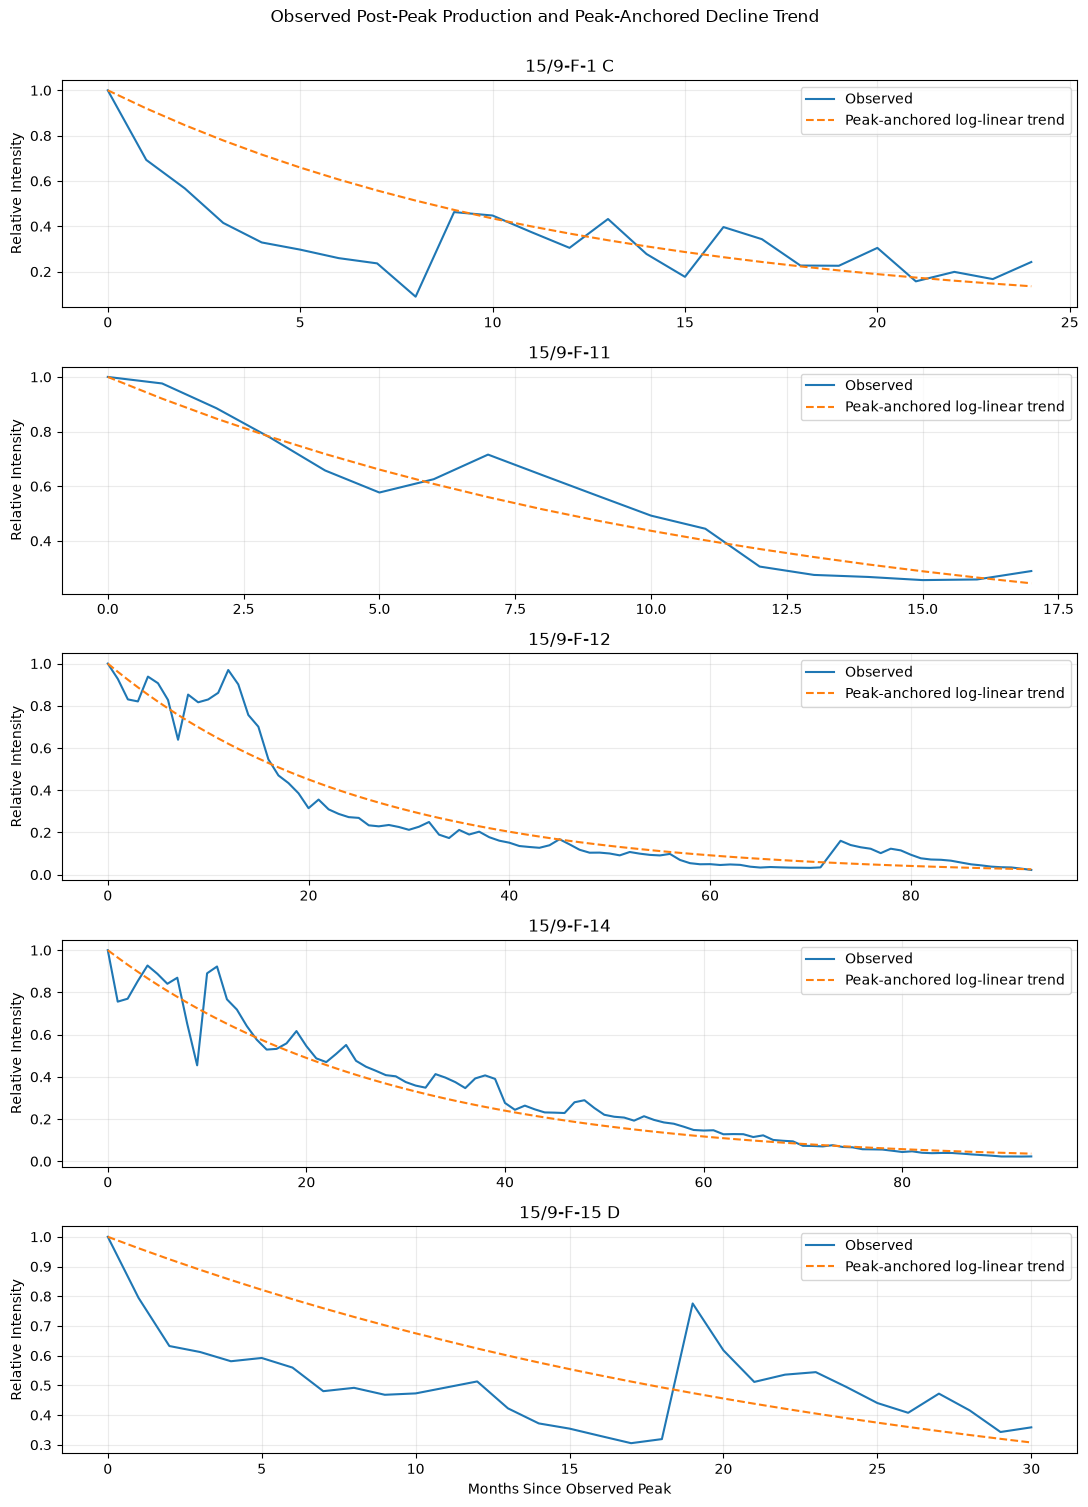

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\02_decline_feature_analysis\05_observed_vs_anchored_decline.png


In [23]:
fig, axes = plt.subplots(
    len(
        eligible_decline_wells
    ),
    1,
    figsize=(
        11,
        3 * len(
            eligible_decline_wells
        )
    ),
    sharex=False
)


for ax, well_name in zip(
    axes,
    eligible_decline_wells
):

    group = (
        post_peak_decline_df[
            post_peak_decline_df[
                "NPD_WELL_BORE_NAME"
            ] == well_name
        ]
        .copy()
        .sort_values(
            "months_since_peak"
        )
    )


    valid_group = (
        group[
            group[
                "relative_intensity"
            ] > 0
        ]
        .copy()
    )


    x = (
        valid_group[
            "months_since_peak"
        ]
        .to_numpy(
            dtype=float
        )
    )


    observed = (
        valid_group[
            "relative_intensity"
        ]
        .to_numpy(
            dtype=float
        )
    )


    y_log = np.log(
        observed
    )


    denominator = np.sum(
        x ** 2
    )


    slope = (
        np.sum(
            x * y_log
        )
        /
        denominator
        if denominator > 0
        else np.nan
    )


    fitted = np.exp(
        slope * x
    )


    ax.plot(
        x,
        observed,
        linewidth=1.5,
        label="Observed"
    )


    ax.plot(
        x,
        fitted,
        linestyle="--",
        linewidth=1.5,
        label="Peak-anchored log-linear trend"
    )


    ax.set_title(
        well_name
    )

    ax.set_ylabel(
        "Relative Intensity"
    )

    ax.grid(
        alpha=0.25
    )

    ax.legend()


axes[-1].set_xlabel(
    "Months Since Observed Peak"
)


fig.suptitle(
    "Observed Post-Peak Production "
    "and Peak-Anchored Decline Trend",
    y=1.002
)


fig.tight_layout()


figure_path = (
    DECLINE_OUTPUT_DIR
    / "05_observed_vs_anchored_decline.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Figure saved:",
    figure_path
)

## 5. Temporal Structure and Candidate Predictive Features

Temporal features such as lagged production and rolling averages are only meaningful when the underlying time sequence is correctly understood.

Before constructing lag features, monthly continuity is checked for each producer. A previous-row value should represent the previous calendar month rather than simply the previous available observation.

This step prevents temporal gaps from being incorrectly interpreted as one-month lags.

In [24]:
temporal_audit_df = (
    well_monthly_decline
    .copy()
    .sort_values(
        [
            "NPD_WELL_BORE_NAME",
            "DATE"
        ]
    )
)


temporal_audit_df[
    "previous_month"
] = (
    temporal_audit_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )["DATE"]
    .shift(1)
)


temporal_audit_df[
    "month_gap"
] = (
    (
        temporal_audit_df["DATE"].dt.year
        -
        temporal_audit_df[
            "previous_month"
        ].dt.year
    )
    * 12
    +
    (
        temporal_audit_df["DATE"].dt.month
        -
        temporal_audit_df[
            "previous_month"
        ].dt.month
    )
)


monthly_gaps = (
    temporal_audit_df[
        temporal_audit_df[
            "month_gap"
        ] > 1
    ]
    .copy()
)


print(
    "Producer-month gaps greater than one month:",
    len(monthly_gaps)
)


display(
    monthly_gaps[
        [
            "NPD_WELL_BORE_NAME",
            "previous_month",
            "DATE",
            "month_gap"
        ]
    ]
)

Producer-month gaps greater than one month: 0


,NPD_WELL_BORE_NAME,previous_month,DATE,month_gap


In [25]:
continuity_summary_rows = []


for well_name, group in (
    temporal_audit_df.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    group = group.sort_values(
        "DATE"
    )


    first_month = (
        group["DATE"].min()
    )

    last_month = (
        group["DATE"].max()
    )


    expected_months = (
        (
            last_month.year
            -
            first_month.year
        )
        * 12
        +
        (
            last_month.month
            -
            first_month.month
        )
        +
        1
    )


    recorded_months = len(group)


    valid_gaps = (
        group[
            "month_gap"
        ]
        .dropna()
    )


    continuity_summary_rows.append({
        "well":
            well_name,

        "first_month":
            first_month,

        "last_month":
            last_month,

        "expected_calendar_months":
            expected_months,

        "recorded_months":
            recorded_months,

        "missing_calendar_months":
            (
                expected_months
                -
                recorded_months
            ),

        "maximum_month_gap":
            (
                valid_gaps.max()
                if len(valid_gaps) > 0
                else np.nan
            )
    })


temporal_continuity_summary = (
    pd.DataFrame(
        continuity_summary_rows
    )
)


display(
    temporal_continuity_summary
)

,well,first_month,last_month,expected_calendar_months,recorded_months,missing_calendar_months,maximum_month_gap
0,15/9-F-1 C,2014-04-01,2016-04-01,25,25,0,1.0
1,15/9-F-11,2013-07-01,2016-09-01,39,39,0,1.0
2,15/9-F-12,2008-02-01,2016-09-01,104,104,0,1.0
3,15/9-F-14,2008-02-01,2016-09-01,104,104,0,1.0
4,15/9-F-15 D,2014-01-01,2016-09-01,33,33,0,1.0
5,15/9-F-5,2016-04-01,2016-09-01,6,6,0,1.0


In [26]:
all_monthly_sequences_continuous = (
    (
        temporal_continuity_summary[
            "missing_calendar_months"
        ] == 0
    )
    .all()
)


print(
    "All producer monthly sequences continuous:",
    all_monthly_sequences_continuous
)

All producer monthly sequences continuous: True


### 5.1 Construction of Leakage-Safe Historical Features

Because all producer monthly sequences are continuous, row-based lag operations can be interpreted as calendar-month lags.

Candidate temporal features are constructed using only information available from the current or earlier months. Rolling statistics are shifted before calculation so that they summarise historical observations without including the value from the month being predicted.

These features are exploratory at this stage. Their predictive usefulness will be evaluated before a final machine learning target or model is selected.

In [27]:
temporal_feature_df = (
    well_monthly_decline
    .copy()
    .sort_values(
        [
            "NPD_WELL_BORE_NAME",
            "DATE"
        ]
    )
    .reset_index(
        drop=True
    )
)


temporal_feature_df[
    "oil_per_on_stream_hour"
] = np.where(
    temporal_feature_df[
        "on_stream_hours"
    ] > 0,

    temporal_feature_df[
        "oil_volume"
    ]
    /
    temporal_feature_df[
        "on_stream_hours"
    ],

    np.nan
)


temporal_feature_df[
    "total_liquid_volume"
] = (
    temporal_feature_df[
        "oil_volume"
    ]
    +
    temporal_feature_df[
        "water_volume"
    ]
)


temporal_feature_df[
    "water_cut_pct"
] = np.where(
    temporal_feature_df[
        "total_liquid_volume"
    ] > 0,

    (
        temporal_feature_df[
            "water_volume"
        ]
        /
        temporal_feature_df[
            "total_liquid_volume"
        ]
    )
    * 100,

    np.nan
)


temporal_feature_df[
    "gas_oil_ratio"
] = np.where(
    temporal_feature_df[
        "oil_volume"
    ] > 0,

    temporal_feature_df[
        "gas_volume"
    ]
    /
    temporal_feature_df[
        "oil_volume"
    ],

    np.nan
)


display(
    temporal_feature_df[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "production_age_months",
            "oil_volume",
            "on_stream_hours",
            "oil_per_on_stream_hour",
            "water_cut_pct",
            "gas_oil_ratio"
        ]
    ]
    .head(10)
)

,NPD_WELL_BORE_NAME,DATE,production_age_months,oil_volume,on_stream_hours,oil_per_on_stream_hour,water_cut_pct,gas_oil_ratio
0,15/9-F-1 C,2014-04-01,0,11142.47,227.50000,48.977890,0.000000,143.409554
1,15/9-F-1 C,2014-05-01,1,24901.95,733.83334,33.934067,3.050290,140.399834
2,15/9-F-1 C,2014-06-01,2,19617.76,705.91666,27.790476,9.538214,147.145326
3,15/9-F-1 C,2014-07-01,3,15085.68,742.41666,20.319695,29.273697,149.106023
4,15/9-F-1 C,2014-08-01,4,6970.43,432.99166,16.098301,39.388514,150.376777
5,15/9-F-1 C,2014-09-01,5,9168.43,630.30000,14.546137,47.567085,154.235784
6,15/9-F-1 C,2014-10-01,6,9468.06,745.00000,12.708805,52.260912,154.420651
7,15/9-F-1 C,2014-11-01,7,6710.33,579.77500,11.574024,51.878545,155.609083
8,15/9-F-1 C,2014-12-01,8,120.29,27.50000,4.374182,60.395746,214.956189
9,15/9-F-1 C,2015-01-01,9,10875.53,479.91667,22.661288,38.647594,147.573001


In [28]:
lag_source_columns = [
    "oil_volume",
    "oil_per_on_stream_hour",
    "water_cut_pct",
    "gas_oil_ratio",
    "on_stream_hours"
]


for column in lag_source_columns:

    for lag in [1, 2, 3]:

        temporal_feature_df[
            f"{column}_lag_{lag}"
        ] = (
            temporal_feature_df
            .groupby(
                "NPD_WELL_BORE_NAME"
            )[column]
            .shift(lag)
        )


print(
    "Lag features created."
)


lag_columns = [
    column
    for column
    in temporal_feature_df.columns
    if "_lag_" in column
]


print(
    "Number of lag features:",
    len(lag_columns)
)


print(
    lag_columns
)

Lag features created.
Number of lag features: 15
['oil_volume_lag_1', 'oil_volume_lag_2', 'oil_volume_lag_3', 'oil_per_on_stream_hour_lag_1', 'oil_per_on_stream_hour_lag_2', 'oil_per_on_stream_hour_lag_3', 'water_cut_pct_lag_1', 'water_cut_pct_lag_2', 'water_cut_pct_lag_3', 'gas_oil_ratio_lag_1', 'gas_oil_ratio_lag_2', 'gas_oil_ratio_lag_3', 'on_stream_hours_lag_1', 'on_stream_hours_lag_2', 'on_stream_hours_lag_3']


In [29]:
rolling_source_columns = [
    "oil_volume",
    "oil_per_on_stream_hour",
    "water_cut_pct",
    "on_stream_hours"
]


for column in rolling_source_columns:

    temporal_feature_df[
        f"{column}_rolling_mean_3"
    ] = (
        temporal_feature_df
        .groupby(
            "NPD_WELL_BORE_NAME"
        )[column]
        .transform(
            lambda series:
                series
                .shift(1)
                .rolling(
                    window=3,
                    min_periods=3
                )
                .mean()
        )
    )


rolling_columns = [
    column
    for column
    in temporal_feature_df.columns
    if "rolling_mean" in column
]


print(
    "Rolling features created:"
)

print(
    rolling_columns
)


display(
    temporal_feature_df[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            "oil_volume_lag_1",
            "oil_volume_lag_2",
            "oil_volume_lag_3",
            "oil_volume_rolling_mean_3"
        ]
    ]
    .head(12)
)

Rolling features created:
['oil_volume_rolling_mean_3', 'oil_per_on_stream_hour_rolling_mean_3', 'water_cut_pct_rolling_mean_3', 'on_stream_hours_rolling_mean_3']


,NPD_WELL_BORE_NAME,DATE,oil_volume,oil_volume_lag_1,oil_volume_lag_2,oil_volume_lag_3,oil_volume_rolling_mean_3
0,15/9-F-1 C,2014-04-01,11142.47,NaN,NaN,NaN,NaN
1,15/9-F-1 C,2014-05-01,24901.95,11142.47,NaN,NaN,NaN
2,15/9-F-1 C,2014-06-01,19617.76,24901.95,11142.47,NaN,NaN
3,15/9-F-1 C,2014-07-01,15085.68,19617.76,24901.95,11142.47,18554.060000
4,15/9-F-1 C,2014-08-01,6970.43,15085.68,19617.76,24901.95,19868.463333
5,15/9-F-1 C,2014-09-01,9168.43,6970.43,15085.68,19617.76,13891.290000
6,15/9-F-1 C,2014-10-01,9468.06,9168.43,6970.43,15085.68,10408.180000
7,15/9-F-1 C,2014-11-01,6710.33,9468.06,9168.43,6970.43,8535.640000
8,15/9-F-1 C,2014-12-01,120.29,6710.33,9468.06,9168.43,8448.940000
9,15/9-F-1 C,2015-01-01,10875.53,120.29,6710.33,9468.06,5432.893333


## 6. Candidate Next-Month Forecasting Targets

The forecasting origin is defined as the end of the current month.

Information observed up to and including month \(t\) may therefore be used to predict production in month \(t+1\). No information from the future target month is used as a predictor.

Two candidate forecasting targets are examined:

1. **Next-month oil volume**, which represents realised monthly oil production and therefore reflects both production performance and operational downtime.

2. **Next-month oil production intensity**, measured as oil volume per on-stream hour. This reduces the direct influence of operating duration but is only defined when the target month contains positive on-stream hours.

The candidates are compared before a final machine learning target is selected.

In [30]:
forecast_base_df = (
    temporal_feature_df[
        temporal_feature_df[
            "production_age_months"
        ] >= 0
    ]
    .copy()
    .sort_values(
        [
            "NPD_WELL_BORE_NAME",
            "DATE"
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "Producer-month observations before "
    "first-active filtering:",
    len(temporal_feature_df)
)

print(
    "Observations from first active month onward:",
    len(forecast_base_df)
)

print(
    "Producer wells retained:",
    forecast_base_df[
        "NPD_WELL_BORE_NAME"
    ].nunique()
)

Producer-month observations before first-active filtering: 311
Observations from first active month onward: 306
Producer wells retained: 6


### Recalculation of Historical Features After Production Start

Historical lag and rolling features are recalculated after restricting each well to its observed production life.

This prevents pre-active records from being treated as valid production history. In particular, the F-14 well contains several zero-production records before its first active production month, which should not supply lagged production information for the active forecasting period.

In [31]:
# Recalculate lag features using only the post-start
# forecasting timeline.

for column in lag_source_columns:

    for lag in [1, 2, 3]:

        forecast_base_df[
            f"{column}_lag_{lag}"
        ] = (
            forecast_base_df
            .groupby(
                "NPD_WELL_BORE_NAME"
            )[column]
            .shift(lag)
        )


# Recalculate rolling features using only
# post-start historical observations.

for column in rolling_source_columns:

    forecast_base_df[
        f"{column}_rolling_mean_3"
    ] = (
        forecast_base_df
        .groupby(
            "NPD_WELL_BORE_NAME"
        )[column]
        .transform(
            lambda series:
                series
                .shift(1)
                .rolling(
                    window=3,
                    min_periods=3
                )
                .mean()
        )
    )


print(
    "Post-start lag and rolling features recalculated."
)

Post-start lag and rolling features recalculated.


In [32]:
f14_history_check = (
    forecast_base_df[
        forecast_base_df[
            "NPD_WELL_BORE_NAME"
        ] == "15/9-F-14"
    ]
    [
        [
            "DATE",
            "production_age_months",
            "oil_volume",
            "oil_volume_lag_1",
            "oil_volume_lag_2",
            "oil_volume_lag_3",
            "oil_volume_rolling_mean_3"
        ]
    ]
    .head(6)
)


display(
    f14_history_check
)

,DATE,production_age_months,oil_volume,oil_volume_lag_1,oil_volume_lag_2,oil_volume_lag_3,oil_volume_rolling_mean_3
168,2008-07-01,0,51285.08,NaN,NaN,NaN,NaN
169,2008-08-01,1,67621.20,51285.08,NaN,NaN,NaN
170,2008-09-01,2,114596.26,67621.20,51285.08,NaN,NaN
171,2008-10-01,3,142817.06,114596.26,67621.20,51285.08,77834.180000
172,2008-11-01,4,104409.61,142817.06,114596.26,67621.20,108344.840000
173,2008-12-01,5,110199.28,104409.61,142817.06,114596.26,120607.643333


In [33]:
forecast_base_df[
    "target_next_month_oil_volume"
] = (
    forecast_base_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )["oil_volume"]
    .shift(-1)
)


forecast_base_df[
    "target_next_month_oil_intensity"
] = (
    forecast_base_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )[
        "oil_per_on_stream_hour"
    ]
    .shift(-1)
)


forecast_base_df[
    "target_next_month_on_stream_hours"
] = (
    forecast_base_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )["on_stream_hours"]
    .shift(-1)
)


display(
    forecast_base_df[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            "oil_per_on_stream_hour",
            "target_next_month_oil_volume",
            "target_next_month_oil_intensity",
            "target_next_month_on_stream_hours"
        ]
    ]
    .head(12)
)

,NPD_WELL_BORE_NAME,DATE,oil_volume,oil_per_on_stream_hour,target_next_month_oil_volume,target_next_month_oil_intensity,target_next_month_on_stream_hours
0,15/9-F-1 C,2014-04-01,11142.47,48.977890,24901.95,33.934067,733.83334
1,15/9-F-1 C,2014-05-01,24901.95,33.934067,19617.76,27.790476,705.91666
2,15/9-F-1 C,2014-06-01,19617.76,27.790476,15085.68,20.319695,742.41666
3,15/9-F-1 C,2014-07-01,15085.68,20.319695,6970.43,16.098301,432.99166
4,15/9-F-1 C,2014-08-01,6970.43,16.098301,9168.43,14.546137,630.30000
5,15/9-F-1 C,2014-09-01,9168.43,14.546137,9468.06,12.708805,745.00000
6,15/9-F-1 C,2014-10-01,9468.06,12.708805,6710.33,11.574024,579.77500
7,15/9-F-1 C,2014-11-01,6710.33,11.574024,120.29,4.374182,27.50000
8,15/9-F-1 C,2014-12-01,120.29,4.374182,10875.53,22.661288,479.91667
9,15/9-F-1 C,2015-01-01,10875.53,22.661288,9586.64,21.916494,437.41667


In [34]:
target_availability_summary = pd.DataFrame({
    "candidate_target": [
        "Next-month oil volume",
        "Next-month oil intensity"
    ],

    "available_observations": [
        forecast_base_df[
            "target_next_month_oil_volume"
        ].notna().sum(),

        forecast_base_df[
            "target_next_month_oil_intensity"
        ].notna().sum()
    ],

    "missing_observations": [
        forecast_base_df[
            "target_next_month_oil_volume"
        ].isna().sum(),

        forecast_base_df[
            "target_next_month_oil_intensity"
        ].isna().sum()
    ]
})


display(
    target_availability_summary
)

,candidate_target,available_observations,missing_observations
0,Next-month oil volume,300,6
1,Next-month oil intensity,292,14


In [35]:
intensity_target_missing = (
    forecast_base_df[
        forecast_base_df[
            "target_next_month_oil_volume"
        ].notna()
        &
        forecast_base_df[
            "target_next_month_oil_intensity"
        ].isna()
    ]
    .copy()
)


print(
    "Rows with a valid next-month oil-volume target "
    "but unavailable intensity target:",
    len(intensity_target_missing)
)


display(
    intensity_target_missing[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "target_next_month_oil_volume",
            "target_next_month_on_stream_hours"
        ]
    ]
)

Rows with a valid next-month oil-volume target but unavailable intensity target: 8


,NPD_WELL_BORE_NAME,DATE,target_next_month_oil_volume,target_next_month_on_stream_hours
145,15/9-F-12,2014-11-01,0.0,0.0
166,15/9-F-12,2016-08-01,0.0,0.0
264,15/9-F-14,2016-07-01,0.0,0.0
265,15/9-F-14,2016-08-01,0.0,0.0
277,15/9-F-15 D,2014-11-01,0.0,0.0
297,15/9-F-15 D,2016-07-01,0.0,0.0
298,15/9-F-15 D,2016-08-01,0.0,0.0
304,15/9-F-5,2016-08-01,0.0,0.0


### 6.1 Primary Forecasting Target

The target comparison shows that next-month oil volume provides broader and more operationally complete coverage than next-month oil production intensity.

Next-month oil volume is therefore selected as the primary forecasting target for subsequent machine learning development.

This target represents realised production and retains inactive or shutdown months where oil production is zero. In contrast, production intensity is undefined when the target well has zero on-stream hours and therefore represents a conditional productivity measure rather than a complete production outcome.

Oil production intensity remains useful for exploratory analysis and as a historical predictor, but it is not selected as the primary forecasting target.

The forecasting problem is therefore defined as:

**Using information available up to and including month \(t\), predict the oil production volume of the same well in month \(t+1\).**

Future variables from month \(t+1\), including target-month on-stream hours or fluid measurements, are not permitted as model inputs.

## 7. Forecasting Sample and Target Suitability

The selected next-month oil-volume target is examined across producer wells before model development.

This step evaluates the number of forecasting observations available for each well, the frequency of zero-production target months, and differences in production scale.

These characteristics are important when deciding whether forecasting should be performed using one pooled multi-well model or separate well-specific models.

In [36]:
target_sample_summary = (
    forecast_base_df[
        forecast_base_df[
            "target_next_month_oil_volume"
        ].notna()
    ]
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .agg(
        forecasting_observations=(
            "target_next_month_oil_volume",
            "size"
        ),

        zero_oil_targets=(
            "target_next_month_oil_volume",
            lambda series:
                (series == 0).sum()
        ),

        mean_target_oil=(
            "target_next_month_oil_volume",
            "mean"
        ),

        median_target_oil=(
            "target_next_month_oil_volume",
            "median"
        ),

        maximum_target_oil=(
            "target_next_month_oil_volume",
            "max"
        )
    )
    .reset_index()
)


target_sample_summary[
    "zero_target_pct"
] = (
    target_sample_summary[
        "zero_oil_targets"
    ]
    /
    target_sample_summary[
        "forecasting_observations"
    ]
    * 100
).round(2)


display(
    target_sample_summary
)

,NPD_WELL_BORE_NAME,forecasting_observations,zero_oil_targets,mean_target_oil,median_target_oil,maximum_target_oil,zero_target_pct
0,15/9-F-1 C,24,0,6940.285833,5298.625,24901.95,0.00
1,15/9-F-11,38,0,30103.316316,31550.705,55029.22,0.00
2,15/9-F-12,103,2,43985.616408,19612.850,166439.67,1.94
3,15/9-F-14,98,2,39703.554184,28892.210,142817.06,2.04
4,15/9-F-15 D,32,3,4463.872812,4562.725,7898.60,9.38
5,15/9-F-5,5,1,7552.014000,9121.480,9985.29,20.00


In [37]:
valid_forecast_targets = (
    forecast_base_df[
        forecast_base_df[
            "target_next_month_oil_volume"
        ].notna()
    ]
    .copy()
)


overall_target_summary = pd.DataFrame({
    "metric": [
        "Forecasting observations",
        "Producer wells",
        "Zero-production target months",
        "Zero-production target percentage",
        "Minimum target oil volume",
        "Median target oil volume",
        "Mean target oil volume",
        "Maximum target oil volume"
    ],

    "value": [
        len(valid_forecast_targets),

        valid_forecast_targets[
            "NPD_WELL_BORE_NAME"
        ].nunique(),

        (
            valid_forecast_targets[
                "target_next_month_oil_volume"
            ] == 0
        ).sum(),

        (
            (
                valid_forecast_targets[
                    "target_next_month_oil_volume"
                ] == 0
            ).mean()
            * 100
        ),

        valid_forecast_targets[
            "target_next_month_oil_volume"
        ].min(),

        valid_forecast_targets[
            "target_next_month_oil_volume"
        ].median(),

        valid_forecast_targets[
            "target_next_month_oil_volume"
        ].mean(),

        valid_forecast_targets[
            "target_next_month_oil_volume"
        ].max()
    ]
})


display(
    overall_target_summary
)

,metric,value
0,Forecasting observations,300.000000
1,Producer wells,6.000000
2,Zero-production target months,8.000000
3,Zero-production target percentage,2.666667
4,Minimum target oil volume,0.000000
5,Median target oil volume,18628.815000
6,Mean target oil volume,33041.878933
7,Maximum target oil volume,166439.670000


### 7.1 Forecast-Time Feature Availability

A variable may be statistically related to future production but still be unsuitable as a predictor if it would not be known when the forecast is generated.

The forecasting origin is the end of month \(t\). Therefore, measurements from month \(t\) and earlier are available, while measurements belonging to target month \(t+1\) are unavailable.

Candidate features are classified according to this forecasting-time constraint before modelling begins.

In [38]:
feature_suitability = pd.DataFrame({
    "candidate_feature": [
        "Well identity",
        "Production age at month t",
        "Current oil volume",
        "Current oil production intensity",
        "Current water cut",
        "Current gas-oil ratio",
        "Current on-stream hours",
        "Lagged oil volume",
        "Lagged oil production intensity",
        "Lagged water cut",
        "Lagged gas-oil ratio",
        "Lagged on-stream hours",
        "Historical rolling production",
        "Target-month on-stream hours",
        "Target-month water cut",
        "Target-month gas-oil ratio"
    ],

    "available_at_forecast_time": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "No",
        "No",
        "No"
    ],

    "modelling_status": [
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Exclude - future leakage",
        "Exclude - future leakage",
        "Exclude - future leakage"
    ]
})


display(
    feature_suitability
)

,candidate_feature,available_at_forecast_time,modelling_status
0,Well identity,Yes,Candidate
1,Production age at month t,Yes,Candidate
2,Current oil volume,Yes,Candidate
3,Current oil production intensity,Yes,Candidate
4,Current water cut,Yes,Candidate
5,Current gas-oil ratio,Yes,Candidate
6,Current on-stream hours,Yes,Candidate
7,Lagged oil volume,Yes,Candidate
8,Lagged oil production intensity,Yes,Candidate
9,Lagged water cut,Yes,Candidate


### 7.2 Multi-Well Modelling Scope

The forecasting sample is highly uneven across producer wells.

The long-history producers F-12 and F-14 provide most of the available forecasting observations, while several other wells contain substantially shorter production histories. In particular, F-5 provides too few observations to support a reliable independent machine learning model.

For subsequent model development, the primary dataset will therefore use a pooled multi-well forecasting structure.

Well identity will be retained as a categorical predictor so that well-specific differences can be represented. Model performance will later be evaluated both across the complete forecasting sample and separately by well so that strong performance on the long-history producers does not hide poor performance on smaller wells.

This decision defines the modelling structure only. No machine learning algorithm is selected at this stage.

In [39]:
feature_audit_df = (
    forecast_base_df[
        forecast_base_df[
            "target_next_month_oil_volume"
        ].notna()
    ]
    .copy()
)


candidate_feature_columns = [
    "production_age_months",

    "oil_volume",
    "oil_per_on_stream_hour",
    "water_cut_pct",
    "gas_oil_ratio",
    "on_stream_hours",

    "oil_volume_lag_1",
    "oil_volume_lag_2",
    "oil_volume_lag_3",

    "oil_per_on_stream_hour_lag_1",
    "oil_per_on_stream_hour_lag_2",
    "oil_per_on_stream_hour_lag_3",

    "water_cut_pct_lag_1",
    "water_cut_pct_lag_2",
    "water_cut_pct_lag_3",

    "gas_oil_ratio_lag_1",
    "gas_oil_ratio_lag_2",
    "gas_oil_ratio_lag_3",

    "on_stream_hours_lag_1",
    "on_stream_hours_lag_2",
    "on_stream_hours_lag_3",

    "oil_volume_rolling_mean_3",
    "oil_per_on_stream_hour_rolling_mean_3",
    "water_cut_pct_rolling_mean_3",
    "on_stream_hours_rolling_mean_3"
]


feature_coverage_rows = []


for column in candidate_feature_columns:

    available_count = (
        feature_audit_df[
            column
        ]
        .notna()
        .sum()
    )

    missing_count = (
        feature_audit_df[
            column
        ]
        .isna()
        .sum()
    )

    feature_coverage_rows.append({
        "feature":
            column,

        "available_observations":
            available_count,

        "missing_observations":
            missing_count,

        "missing_pct":
            (
                missing_count
                /
                len(feature_audit_df)
                * 100
            )
    })


feature_coverage_summary = (
    pd.DataFrame(
        feature_coverage_rows
    )
)


feature_coverage_summary[
    "missing_pct"
] = (
    feature_coverage_summary[
        "missing_pct"
    ]
    .round(2)
)


display(
    feature_coverage_summary
    .sort_values(
        [
            "missing_pct",
            "feature"
        ]
    )
)

,feature,available_observations,missing_observations,missing_pct
1,oil_volume,300,0,0.00
5,on_stream_hours,300,0,0.00
0,production_age_months,300,0,0.00
4,gas_oil_ratio,296,4,1.33
2,oil_per_on_stream_hour,296,4,1.33
3,water_cut_pct,296,4,1.33
6,oil_volume_lag_1,294,6,2.00
18,on_stream_hours_lag_1,294,6,2.00
15,gas_oil_ratio_lag_1,292,8,2.67
9,oil_per_on_stream_hour_lag_1,292,8,2.67


In [40]:
feature_history_groups = {

    "Current-month core":
        [
            "production_age_months",
            "oil_volume",
            "on_stream_hours"
        ],

    "Core + 1-month oil lag":
        [
            "production_age_months",
            "oil_volume",
            "on_stream_hours",
            "oil_volume_lag_1"
        ],

    "Core + oil lags 1-3":
        [
            "production_age_months",
            "oil_volume",
            "on_stream_hours",
            "oil_volume_lag_1",
            "oil_volume_lag_2",
            "oil_volume_lag_3"
        ],

    "Core + oil lags + 3-month rolling oil":
        [
            "production_age_months",
            "oil_volume",
            "on_stream_hours",
            "oil_volume_lag_1",
            "oil_volume_lag_2",
            "oil_volume_lag_3",
            "oil_volume_rolling_mean_3"
        ]
}


history_coverage_rows = []


for group_name, columns in (
    feature_history_groups.items()
):

    complete_rows = (
        feature_audit_df[
            columns
        ]
        .notna()
        .all(
            axis=1
        )
        .sum()
    )


    history_coverage_rows.append({
        "feature_group":
            group_name,

        "complete_rows":
            complete_rows,

        "rows_lost":
            (
                len(feature_audit_df)
                -
                complete_rows
            ),

        "retained_pct":
            (
                complete_rows
                /
                len(feature_audit_df)
                * 100
            )
    })


history_coverage_summary = (
    pd.DataFrame(
        history_coverage_rows
    )
)


history_coverage_summary[
    "retained_pct"
] = (
    history_coverage_summary[
        "retained_pct"
    ]
    .round(2)
)


display(
    history_coverage_summary
)

,feature_group,complete_rows,rows_lost,retained_pct
0,Current-month core,300,0,100.0
1,Core + 1-month oil lag,294,6,98.0
2,Core + oil lags 1-3,282,18,94.0
3,Core + oil lags + 3-month rolling oil,282,18,94.0


In [41]:
well_history_coverage_rows = []


required_history_features = [
    "oil_volume_lag_1",
    "oil_volume_lag_2",
    "oil_volume_lag_3",
    "oil_volume_rolling_mean_3"
]


for well_name, group in (
    feature_audit_df.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    total_rows = len(group)

    complete_history_rows = (
        group[
            required_history_features
        ]
        .notna()
        .all(
            axis=1
        )
        .sum()
    )


    well_history_coverage_rows.append({
        "well":
            well_name,

        "forecasting_rows":
            total_rows,

        "rows_with_complete_3_month_history":
            complete_history_rows,

        "rows_lost":
            (
                total_rows
                -
                complete_history_rows
            ),

        "retained_pct":
            (
                complete_history_rows
                /
                total_rows
                * 100
            )
    })


well_history_coverage_summary = (
    pd.DataFrame(
        well_history_coverage_rows
    )
)


well_history_coverage_summary[
    "retained_pct"
] = (
    well_history_coverage_summary[
        "retained_pct"
    ]
    .round(2)
)


display(
    well_history_coverage_summary
)

,well,forecasting_rows,rows_with_complete_3_month_history,rows_lost,retained_pct
0,15/9-F-1 C,24,21,3,87.50
1,15/9-F-11,38,35,3,92.11
2,15/9-F-12,103,100,3,97.09
3,15/9-F-14,98,95,3,96.94
4,15/9-F-15 D,32,29,3,90.62
5,15/9-F-5,5,2,3,40.00


## 8. Temporal Predictive Relationships

Candidate predictors are evaluated according to their relationship with next-month oil production.

Because producer wells differ substantially in production scale and lifecycle, relationships are examined within individual wells rather than relying only on pooled correlations.

Only information available by the end of month \(t\) is considered. The target remains oil production in month \(t+1\).

A current-inclusive three-month production average is also constructed. Unlike the earlier historical rolling feature, which uses months \(t-1\) to \(t-3\), this recent-production feature uses months \(t\), \(t-1\), and \(t-2\). Both are valid at the defined forecasting origin.

In [42]:
forecast_base_df[
    "oil_volume_recent_mean_3"
] = (
    forecast_base_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )["oil_volume"]
    .transform(
        lambda series:
            series
            .rolling(
                window=3,
                min_periods=3
            )
            .mean()
    )
)


print(
    "oil_volume_recent_mean_3 created:",
    "oil_volume_recent_mean_3"
    in forecast_base_df.columns
)

oil_volume_recent_mean_3 created: True


In [43]:
relationship_features = [
    "oil_volume",
    "oil_volume_lag_1",
    "oil_volume_lag_2",
    "oil_volume_lag_3",
    "oil_volume_recent_mean_3",
    "oil_volume_rolling_mean_3",
    "production_age_months",
    "oil_per_on_stream_hour",
    "water_cut_pct",
    "gas_oil_ratio",
    "on_stream_hours"
]


print(
    "Number of relationship features:",
    len(relationship_features)
)


print(
    relationship_features
)

Number of relationship features: 11
['oil_volume', 'oil_volume_lag_1', 'oil_volume_lag_2', 'oil_volume_lag_3', 'oil_volume_recent_mean_3', 'oil_volume_rolling_mean_3', 'production_age_months', 'oil_per_on_stream_hour', 'water_cut_pct', 'gas_oil_ratio', 'on_stream_hours']


In [44]:
required_relationship_columns = (
    relationship_features
    +
    [
        "target_next_month_oil_volume"
    ]
)


missing_relationship_columns = [
    column
    for column in required_relationship_columns
    if column
    not in forecast_base_df.columns
]


print(
    "Missing required columns:",
    missing_relationship_columns
)

Missing required columns: []


In [45]:
relationship_rows = []


for well_name, well_group in (
    forecast_base_df.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    for feature in relationship_features:

        valid_pairs = (
            well_group[
                [
                    feature,
                    "target_next_month_oil_volume"
                ]
            ]
            .dropna()
        )


        observation_count = len(
            valid_pairs
        )


        if observation_count >= 12:

            correlation = (
                valid_pairs[
                    feature
                ]
                .corr(
                    valid_pairs[
                        "target_next_month_oil_volume"
                    ],
                    method="spearman"
                )
            )

        else:

            correlation = np.nan


        relationship_rows.append({
            "well":
                well_name,

            "feature":
                feature,

            "valid_observations":
                observation_count,

            "spearman_correlation":
                correlation
        })


well_feature_relationships = (
    pd.DataFrame(
        relationship_rows
    )
)


well_feature_relationships[
    "spearman_correlation"
] = (
    well_feature_relationships[
        "spearman_correlation"
    ]
    .round(4)
)


display(
    well_feature_relationships
)

,well,feature,valid_observations,spearman_correlation
0,15/9-F-1 C,oil_volume,24,0.5383
1,15/9-F-1 C,oil_volume_lag_1,23,0.3370
2,15/9-F-1 C,oil_volume_lag_2,22,0.5212
3,15/9-F-1 C,oil_volume_lag_3,21,0.6130
4,15/9-F-1 C,oil_volume_recent_mean_3,22,0.5110
...,...,...,...,...
61,15/9-F-5,production_age_months,5,NaN
62,15/9-F-5,oil_per_on_stream_hour,5,NaN
63,15/9-F-5,water_cut_pct,5,NaN
64,15/9-F-5,gas_oil_ratio,5,NaN


In [46]:
relationship_summary = (
    well_feature_relationships[
        well_feature_relationships[
            "spearman_correlation"
        ].notna()
    ]
    .groupby(
        "feature"
    )
    .agg(
        wells_evaluated=(
            "well",
            "nunique"
        ),

        median_spearman=(
            "spearman_correlation",
            "median"
        ),

        minimum_spearman=(
            "spearman_correlation",
            "min"
        ),

        maximum_spearman=(
            "spearman_correlation",
            "max"
        ),

        positive_relationship_wells=(
            "spearman_correlation",
            lambda series:
                (series > 0).sum()
        ),

        negative_relationship_wells=(
            "spearman_correlation",
            lambda series:
                (series < 0).sum()
        )
    )
    .reset_index()
)


relationship_summary[
    [
        "median_spearman",
        "minimum_spearman",
        "maximum_spearman"
    ]
] = (
    relationship_summary[
        [
            "median_spearman",
            "minimum_spearman",
            "maximum_spearman"
        ]
    ]
    .round(4)
)


relationship_summary[
    "absolute_median_spearman"
] = (
    relationship_summary[
        "median_spearman"
    ]
    .abs()
)


relationship_summary = (
    relationship_summary
    .sort_values(
        "absolute_median_spearman",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    relationship_summary
)

,feature,wells_evaluated,median_spearman,minimum_spearman,maximum_spearman,positive_relationship_wells,negative_relationship_wells,absolute_median_spearman
0,oil_per_on_stream_hour,5,0.7818,0.6078,0.9647,5,0,0.7818
1,water_cut_pct,5,-0.7783,-0.9678,-0.3597,0,5,0.7783
2,production_age_months,5,-0.7383,-0.9642,-0.3358,0,5,0.7383
3,oil_volume,5,0.6720,0.4438,0.9454,5,0,0.6720
4,oil_volume_lag_3,5,0.6130,-0.0356,0.9092,4,1,0.6130
5,gas_oil_ratio,5,-0.5872,-0.6613,-0.3073,0,5,0.5872
6,oil_volume_lag_2,5,0.5212,0.0873,0.9201,5,0,0.5212
7,oil_volume_recent_mean_3,5,0.5110,0.3546,0.9514,5,0,0.5110
8,oil_volume_rolling_mean_3,5,0.5013,0.2580,0.9435,5,0,0.5013
9,oil_volume_lag_1,5,0.3957,0.3259,0.9096,5,0,0.3957


## 9. Chronological Validation Strategy

A forecasting model must be evaluated using future observations that occur after the observations used for model development.

Random train-test splitting is therefore inappropriate for this project because it would allow observations from later periods to contribute to model training while earlier observations are used for testing.

The modelling workflow will instead use chronological validation.

Because producer wells entered production at different times and contain unequal history lengths, candidate calendar cutoffs are examined before selecting the final holdout period.

F-5 is retained in the overall dataset and descriptive analysis but is not used to determine the primary validation structure because its five forecasting observations are insufficient for reliable independent temporal evaluation.

In [47]:
core_validation_wells = [
    "15/9-F-1 C",
    "15/9-F-11",
    "15/9-F-12",
    "15/9-F-14",
    "15/9-F-15 D"
]


validation_base_df = (
    forecast_base_df[
        forecast_base_df[
            "NPD_WELL_BORE_NAME"
        ].isin(
            core_validation_wells
        )
        &
        forecast_base_df[
            "target_next_month_oil_volume"
        ].notna()
    ]
    .copy()
    .sort_values(
        [
            "DATE",
            "NPD_WELL_BORE_NAME"
        ]
    )
)


print(
    "Core validation observations:",
    len(validation_base_df)
)

print(
    "Core validation wells:",
    validation_base_df[
        "NPD_WELL_BORE_NAME"
    ].nunique()
)

print(
    "Forecast-origin coverage:",
    validation_base_df["DATE"].min(),
    "to",
    validation_base_df["DATE"].max()
)

Core validation observations: 295
Core validation wells: 5
Forecast-origin coverage: 2008-02-01 00:00:00 to 2016-08-01 00:00:00


In [48]:
candidate_cutoffs = pd.to_datetime([
    "2015-01-01",
    "2015-04-01",
    "2015-07-01"
])


cutoff_rows = []


for cutoff in candidate_cutoffs:

    for well_name, group in (
        validation_base_df.groupby(
            "NPD_WELL_BORE_NAME"
        )
    ):

        train_count = (
            group[
                group["DATE"] < cutoff
            ]
            .shape[0]
        )

        test_count = (
            group[
                group["DATE"] >= cutoff
            ]
            .shape[0]
        )


        cutoff_rows.append({
            "cutoff":
                cutoff,

            "well":
                well_name,

            "train_observations":
                train_count,

            "test_observations":
                test_count
        })


cutoff_evaluation = (
    pd.DataFrame(
        cutoff_rows
    )
)


display(
    cutoff_evaluation
)

,cutoff,well,train_observations,test_observations
0,2015-01-01,15/9-F-1 C,9,15
1,2015-01-01,15/9-F-11,18,20
2,2015-01-01,15/9-F-12,83,20
3,2015-01-01,15/9-F-14,78,20
4,2015-01-01,15/9-F-15 D,12,20
5,2015-04-01,15/9-F-1 C,12,12
6,2015-04-01,15/9-F-11,21,17
7,2015-04-01,15/9-F-12,86,17
8,2015-04-01,15/9-F-14,81,17
9,2015-04-01,15/9-F-15 D,15,17


In [49]:
cutoff_summary = (
    cutoff_evaluation
    .groupby(
        "cutoff"
    )
    .agg(
        total_train_observations=(
            "train_observations",
            "sum"
        ),

        total_test_observations=(
            "test_observations",
            "sum"
        ),

        minimum_train_per_well=(
            "train_observations",
            "min"
        ),

        minimum_test_per_well=(
            "test_observations",
            "min"
        ),

        maximum_train_per_well=(
            "train_observations",
            "max"
        ),

        maximum_test_per_well=(
            "test_observations",
            "max"
        )
    )
    .reset_index()
)


cutoff_summary[
    "test_pct"
] = (
    cutoff_summary[
        "total_test_observations"
    ]
    /
    (
        cutoff_summary[
            "total_train_observations"
        ]
        +
        cutoff_summary[
            "total_test_observations"
        ]
    )
    * 100
).round(2)


display(
    cutoff_summary
)

,cutoff,total_train_observations,total_test_observations,minimum_train_per_well,minimum_test_per_well,maximum_train_per_well,maximum_test_per_well,test_pct
0,2015-01-01,200,95,9,15,83,20,32.20
1,2015-04-01,215,80,12,12,86,17,27.12
2,2015-07-01,230,65,15,9,89,14,22.03


### 9.1 Selected Holdout Strategy

The April 2015 cutoff is selected as the primary final holdout boundary.

This cutoff provides a balance between historical training depth and future evaluation coverage across the five core producer wells. It provides 215 training observations and 80 future holdout observations, while maintaining at least 12 observations per well on both sides of the split.

The final modelling workflow will therefore use:

- observations before April 2015 for model development;
- observations from April 2015 onward as an untouched final holdout set.

Within the pre-holdout development period, expanding-window temporal validation will be used for model comparison and hyperparameter selection.

This preserves chronological order throughout the modelling process and prevents future observations from influencing model development.

In [50]:
FINAL_HOLDOUT_CUTOFF = pd.Timestamp(
    "2015-04-01"
)


development_df = (
    validation_base_df[
        validation_base_df["DATE"]
        < FINAL_HOLDOUT_CUTOFF
    ]
    .copy()
)


final_holdout_df = (
    validation_base_df[
        validation_base_df["DATE"]
        >= FINAL_HOLDOUT_CUTOFF
    ]
    .copy()
)


print(
    "Final holdout cutoff:",
    FINAL_HOLDOUT_CUTOFF
)

print(
    "Development observations:",
    len(development_df)
)

print(
    "Final holdout observations:",
    len(final_holdout_df)
)

print(
    "Development coverage:",
    development_df["DATE"].min(),
    "to",
    development_df["DATE"].max()
)

print(
    "Holdout coverage:",
    final_holdout_df["DATE"].min(),
    "to",
    final_holdout_df["DATE"].max()
)

Final holdout cutoff: 2015-04-01 00:00:00
Development observations: 215
Final holdout observations: 80
Development coverage: 2008-02-01 00:00:00 to 2015-03-01 00:00:00
Holdout coverage: 2015-04-01 00:00:00 to 2016-08-01 00:00:00


In [51]:
split_well_summary = (
    validation_base_df
    .assign(
        split=np.where(
            validation_base_df["DATE"]
            < FINAL_HOLDOUT_CUTOFF,
            "Development",
            "Final Holdout"
        )
    )
    .groupby(
        [
            "NPD_WELL_BORE_NAME",
            "split"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)


display(
    split_well_summary
)

split,NPD_WELL_BORE_NAME,Development,Final Holdout
0,15/9-F-1 C,12,12
1,15/9-F-11,21,17
2,15/9-F-12,86,17
3,15/9-F-14,81,17
4,15/9-F-15 D,15,17


### 9.2 Expanding-Window Model Development

The final holdout set must remain untouched during model development.

Within the pre-April-2015 development period, models will be compared using expanding-window validation. Earlier observations are used to train the model and a later chronological block is used for validation.

As the process advances, the training window expands forward in time while validation always occurs on observations that were not available during model fitting.

This design better represents the intended forecasting scenario than random cross-validation.

## 10. Final Modelling Formulation

The exploratory, decline, temporal, and target analyses support a pooled multi-well next-month oil-production forecasting problem.

The primary prediction task is:

**Using information available up to and including month \(t\), predict the realised oil production volume of the same producer well in month \(t+1\).**

The modelling dataset will retain well identity because producer wells differ substantially in production scale, lifecycle, and decline behaviour.

Candidate predictors supported by the analysis include:

- well identity;
- production age;
- current monthly oil production;
- current oil production intensity;
- current water cut;
- current gas-oil ratio;
- current on-stream hours;
- lagged oil-production history;
- lagged operational and fluid-history variables;
- recent and historical rolling production summaries.

Variables from month \(t+1\) are excluded from model inputs.

The modelling workflow will use chronological expanding-window validation within the development period and an untouched final holdout beginning in April 2015.

Model selection is intentionally deferred to the next stage so that algorithms are compared against the same forecasting definition and validation framework rather than being chosen in advance.

### 10.1 Saving Notebook 02 Outputs

Key analytical summaries are saved as reproducible project outputs.

A modelling-ready monthly forecasting dataset is also exported to the processed-data directory for use in the subsequent predictive modelling notebook.

The processed modelling datasets remain excluded from Git because they can be regenerated from the source data and this notebook. Compact analytical summaries and figures are retained in the project outputs for documentation and portfolio evidence.

In [52]:
# ---------------------------------------------------------
# Save Notebook 02 analytical evidence
# ---------------------------------------------------------

summary_outputs = {
    "06_production_age_summary.csv":
        production_age_summary,

    "07_active_decline_summary.csv":
        active_decline_summary,

    "08_well_peak_summary.csv":
        well_peak_summary,

    "09_early_late_decline_summary.csv":
        decline_change_summary,

    "10_age_intensity_relationship.csv":
        age_intensity_relationship,

    "11_post_peak_coverage.csv":
        post_peak_coverage,

    "12_decline_trend_summary.csv":
        decline_trend_summary,

    "13_temporal_continuity_summary.csv":
        temporal_continuity_summary,

    "14_feature_coverage_summary.csv":
        feature_coverage_summary,

    "15_history_coverage_summary.csv":
        history_coverage_summary,

    "16_well_history_coverage_summary.csv":
        well_history_coverage_summary,

    "17_target_availability_summary.csv":
        target_availability_summary,

    "18_target_sample_summary.csv":
        target_sample_summary,

    "19_overall_target_summary.csv":
        overall_target_summary,

    "20_feature_suitability.csv":
        feature_suitability,

    "21_well_feature_relationships.csv":
        well_feature_relationships,

    "22_relationship_summary.csv":
        relationship_summary,

    "23_validation_cutoff_detail.csv":
        cutoff_evaluation,

    "24_validation_cutoff_summary.csv":
        cutoff_summary,

    "25_split_well_summary.csv":
        split_well_summary
}


for filename, dataframe in summary_outputs.items():

    output_path = (
        DECLINE_OUTPUT_DIR
        / filename
    )

    dataframe.to_csv(
        output_path,
        index=False
    )


print(
    "Analytical CSV outputs saved:",
    len(summary_outputs)
)

Analytical CSV outputs saved: 20


In [53]:
# ---------------------------------------------------------
# Save modelling-ready datasets for Notebook 03
# ---------------------------------------------------------

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)


model_ready_columns = [
    "NPD_WELL_BORE_NAME",
    "DATE",
    "production_age_months",

    "oil_volume",
    "oil_per_on_stream_hour",
    "water_cut_pct",
    "gas_oil_ratio",
    "on_stream_hours",

    "oil_volume_lag_1",
    "oil_volume_lag_2",
    "oil_volume_lag_3",

    "oil_per_on_stream_hour_lag_1",
    "oil_per_on_stream_hour_lag_2",
    "oil_per_on_stream_hour_lag_3",

    "water_cut_pct_lag_1",
    "water_cut_pct_lag_2",
    "water_cut_pct_lag_3",

    "gas_oil_ratio_lag_1",
    "gas_oil_ratio_lag_2",
    "gas_oil_ratio_lag_3",

    "on_stream_hours_lag_1",
    "on_stream_hours_lag_2",
    "on_stream_hours_lag_3",

    "oil_volume_rolling_mean_3",
    "oil_per_on_stream_hour_rolling_mean_3",
    "water_cut_pct_rolling_mean_3",
    "on_stream_hours_rolling_mean_3",

    "oil_volume_recent_mean_3",

    "target_next_month_oil_volume"
]


missing_export_columns = [
    column
    for column in model_ready_columns
    if column
    not in forecast_base_df.columns
]


assert (
    len(missing_export_columns) == 0
), (
    "Missing modelling columns: "
    f"{missing_export_columns}"
)


model_ready_df = (
    forecast_base_df[
        forecast_base_df[
            "target_next_month_oil_volume"
        ].notna()
    ][
        model_ready_columns
    ]
    .copy()
)


development_export_df = (
    model_ready_df[
        model_ready_df[
            "NPD_WELL_BORE_NAME"
        ].isin(
            core_validation_wells
        )
        &
        (
            model_ready_df["DATE"]
            < FINAL_HOLDOUT_CUTOFF
        )
    ]
    .copy()
)


final_holdout_export_df = (
    model_ready_df[
        model_ready_df[
            "NPD_WELL_BORE_NAME"
        ].isin(
            core_validation_wells
        )
        &
        (
            model_ready_df["DATE"]
            >= FINAL_HOLDOUT_CUTOFF
        )
    ]
    .copy()
)


assert len(model_ready_df) == 300

assert (
    len(development_export_df)
    == 215
)

assert (
    len(final_holdout_export_df)
    == 80
)


model_ready_df.to_csv(
    PROCESSED_DATA_DIR
    / "02_modeling_ready_monthly_forecast.csv",
    index=False
)


development_export_df.to_csv(
    PROCESSED_DATA_DIR
    / "02_development_pre_2015_04.csv",
    index=False
)


final_holdout_export_df.to_csv(
    PROCESSED_DATA_DIR
    / "02_final_holdout_2015_04_onward.csv",
    index=False
)


print(
    "Modelling-ready observations:",
    len(model_ready_df)
)

print(
    "Development observations:",
    len(development_export_df)
)

print(
    "Final holdout observations:",
    len(final_holdout_export_df)
)

print(
    "\nNotebook 02 outputs saved successfully."
)

Modelling-ready observations: 300
Development observations: 215
Final holdout observations: 80

Notebook 02 outputs saved successfully.


## 11. Notebook 02 Conclusion

This notebook established the production-decline and forecasting structure required for later machine learning development.

Producer wells were aligned by production age and active operating history so that calendar timing, downtime, and long-term decline were not incorrectly treated as the same process.

The long-history producers F-12 and F-14 showed substantial reductions in production intensity across their observed producing lives. Post-peak analysis also demonstrated that production decline is not uniformly smooth across all wells, with several producers showing rebounds and changing temporal behaviour.

Next-month oil volume was selected as the primary forecasting target because it represents realised production and retains shutdown months that would be excluded by an intensity-only target.

Temporal continuity was verified before lag construction, and historical features were generated using forecast-time-safe information. Three months of oil-production history retained approximately 94% of the available forecasting sample.

Within-well Spearman analysis showed that several current and historical production variables were associated with next-month oil production, although the strength and direction of these relationships differed across wells. These results are used as feature-screening evidence rather than as causal conclusions or proof that a variable will improve forecast accuracy.

Because producer history lengths are highly unequal, the subsequent machine learning stage will use a pooled multi-well modelling structure while evaluating performance both overall and by individual well.

Random train-test splitting is rejected. Model development will use expanding-window chronological validation, followed by an untouched final holdout beginning in April 2015.

The next stage will compare forecasting baselines and machine learning approaches under this fixed modelling framework.